# Train LRN_AD on multilayer RBS data

Based on `train_lrn_multilayer.ipynb`. The network receives elemental areal densities multiplied by `AD_INPUT_FACTOR = 1e-5`, matching IBAnet target units. Export keeps physical thickness and atomic fractions and embeds their conversion to scaled AD in ONNX. No concentration normalization or thickness scaling is applied.


In [ ]:
from pathlib import Path
import os
import re
import zipfile
import tomllib
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

ROOT = Path.cwd().resolve()
if ROOT.name == "examples":
    ROOT = ROOT.parent
EXAMPLES = ROOT / "examples"

import sys
sys.path.append(str(ROOT))

import ibeamlab as ibl
from ibeamlab import transforms
from ibeamlab import LRN_AD



## 1. Choose the dataset

Set the dataset root, generation configuration, method, and layer count here. Preprocessing, model, training, and export settings live beside their respective cells.


In [ ]:
DATASET_ROOT = EXAMPLES / "datasets"
CONFIG_PATH = EXAMPLES / "multilayer-generation.toml"
METHOD = "RBS"
MAX_LAYERS = 10
DATASET_ROOT = DATASET_ROOT.resolve()
if not DATASET_ROOT.is_dir():
    raise FileNotFoundError(DATASET_ROOT)
configuration = ibl.load_generation_configuration(CONFIG_PATH)
if MAX_LAYERS > configuration.maximum_layers:
    raise ValueError("MAX_LAYERS exceeds the generation config limit")
study = configuration.study(MAX_LAYERS)
ELEMENTS = tuple(configuration.elements)
AD_INPUT_FACTOR = 1e-5
if configuration.variations:
    raise ValueError('This LRN_AD notebook requires a fixed setup')

# Each layers_XX directory is one dataset; discover them at any nesting depth.
LAYER_DATASETS = {}
for path in sorted(DATASET_ROOT.rglob("layers_*")):
    match = re.fullmatch(r"layers_(\d+)", path.name)
    if path.is_dir() and match:
        LAYER_DATASETS.setdefault(int(match.group(1)), []).append(path)
if not LAYER_DATASETS:
    raise FileNotFoundError(f"No layers_XX datasets found recursively under {DATASET_ROOT}")

print("Dataset root:", DATASET_ROOT)
print(f"Training layer counts: 1..{MAX_LAYERS}")
print("Study input features:", len(study.parameters))
print(f"Discovered dataset directories: {sum(map(len, LAYER_DATASETS.values()))}")


## 2. Load and combine the datasets

The loader discovers all `layers_XX` datasets recursively, aligns columns by physical parameter name, pads absent deeper layers with zeros, and pads spectra to a shared channel width.


In [3]:
loaded = []
max_spectrum_width = 0
expected_names = study.parameter_names

for layer_count in range(1, MAX_LAYERS + 1):
    dataset_paths = LAYER_DATASETS.get(layer_count, [])
    if not dataset_paths:
        raise FileNotFoundError(f"No dataset found for {layer_count} layers under {DATASET_ROOT}")
    for dataset_path in dataset_paths:
        dataset = ibl.open_dataset(dataset_path)
        if not dataset.metadata.complete:
            raise RuntimeError(f"Dataset is incomplete: {dataset_path}")
        if METHOD not in dataset.metadata.spectrum_labels:
            raise ValueError(f"{dataset_path} has no {METHOD!r} spectrum")
        if dataset.metadata.invalid or dataset.metadata.failed:
            print(f"Note: {dataset_path.name} has invalid={dataset.metadata.invalid}, failed={dataset.metadata.failed}")

        values = np.asarray(dataset.parameters, dtype=np.float32)
        spectra = np.asarray(dataset.spectra(METHOD), dtype=np.float32)
        names = dataset.metadata.parameter_names
        if values.shape[0] != spectra.shape[0] or not values.shape[0]:
            raise ValueError(f"Empty or misaligned arrays in {dataset_path}")
        if len(names) != values.shape[1]:
            raise ValueError(f"Parameter metadata does not match columns in {dataset_path}")
        unknown_names = set(names) - set(expected_names)
        if unknown_names:
            raise ValueError(f"Unexpected parameters in {dataset_path}: {sorted(unknown_names)}")

        name_to_column = {name: column for column, name in enumerate(names)}
        aligned = np.zeros((len(values), len(expected_names)), dtype=np.float32)
        for column, name in enumerate(expected_names):
            if name in name_to_column:
                aligned[:, column] = values[:, name_to_column[name]]
        max_spectrum_width = max(max_spectrum_width, spectra.shape[1])
        loaded.append((aligned, spectra))
        print(f"Loaded {dataset_path}: {len(values):,} samples, {spectra.shape[1]} channels")

x_parts, y_parts = [], []
for values, spectra in loaded:
    if spectra.shape[1] < max_spectrum_width:
        spectra = np.pad(spectra, ((0, 0), (0, max_spectrum_width - spectra.shape[1])))
    x_parts.append(values)
    y_parts.append(spectra)
x_raw = np.concatenate(x_parts, axis=0)
y_raw = np.concatenate(y_parts, axis=0)
if not np.all(np.isfinite(x_raw)) or not np.all(np.isfinite(y_raw)):
    raise ValueError("Training arrays contain NaN or infinite values")
if np.any(y_raw < 0):
    raise ValueError("RBS count targets must be nonnegative")

print("Input matrix:", x_raw.shape, x_raw.dtype)
print("Spectrum matrix:", y_raw.shape, y_raw.dtype)
print("Input range:", float(x_raw.min()), "to", float(x_raw.max()))
print("RBS count range:", float(y_raw.min()), "to", float(y_raw.max()))


Loaded D:\ibeamlab\examples\datasets\iba_multilayer_seed_1\layers_01: 200,000 samples, 2997 channels
Loaded D:\ibeamlab\examples\datasets\iba_multilayer_seed_2\layers_01: 200,000 samples, 2997 channels
Loaded D:\ibeamlab\examples\datasets\iba_multilayer_moreC_seed3\layers_02: 100,000 samples, 2997 channels
Loaded D:\ibeamlab\examples\datasets\iba_multilayer_seed_1\layers_02: 100,000 samples, 2997 channels
Loaded D:\ibeamlab\examples\datasets\iba_multilayer_seed_2\layers_02: 100,000 samples, 2997 channels
Loaded D:\ibeamlab\examples\datasets\iba_multilayer_moreC_seed3\layers_03: 100,000 samples, 2997 channels
Loaded D:\ibeamlab\examples\datasets\iba_multilayer_seed_1\layers_03: 100,000 samples, 2997 channels
Loaded D:\ibeamlab\examples\datasets\iba_multilayer_seed_2\layers_03: 100,000 samples, 2997 channels
Loaded D:\ibeamlab\examples\datasets\iba_multilayer_moreC_seed3\layers_04: 100,000 samples, 2997 channels
Loaded D:\ibeamlab\examples\datasets\iba_multilayer_seed_1\layers_04: 100,00

## 3. Split and scale

Convert valid physical thickness and atomic fractions to elemental AD, then multiply by `AD_INPUT_FACTOR`. Exact padding stays zero. Targets retain the original `OUTPUT_SCALE`. The export graph performs the same input conversion and scaling.


In [4]:
# Split and preprocessing settings
SEED = 7
OUTPUT_SCALE = 1e-2
VALIDATION_FRACTION = 0.10
MAX_VALIDATION_SAMPLES = 20_000
TEST_FRACTION = 0.10
MAX_TEST_SAMPLES = 10_000

if len(x_raw) < 10:
    raise ValueError("At least 10 samples are needed for train/validation/test splits")
order = np.random.default_rng(SEED).permutation(len(x_raw))
validation_count = min(int(VALIDATION_FRACTION * len(order)), MAX_VALIDATION_SAMPLES)
test_count = min(int(TEST_FRACTION * len(order)), MAX_TEST_SAMPLES)
train_end = len(order) - validation_count - test_count
validation_end = train_end + validation_count
train_indices, val_indices, test_indices = order[:train_end], order[train_end:validation_end], order[validation_end:]
x_train_raw, y_train_raw = x_raw[train_indices], y_raw[train_indices]
x_val_raw, y_val_raw = x_raw[val_indices], y_raw[val_indices]
x_test_raw, y_test = x_raw[test_indices], y_raw[test_indices]

def physical_to_ad(values, case_study):
    columns = {p.name: i for i, p in enumerate(case_study.parameters)}
    result = []
    for layer in range(len(case_study.experiment.sample.layers)):
        thickness_parameter = next(p for p in case_study.parameters if p.layer == layer and p.kind == 'layer_thickness')
        thickness = values[:, columns[thickness_parameter.name]]
        concentration_columns = {p.element: columns[p.name] for p in case_study.parameters
                                 if p.layer == layer and p.kind == 'concentration'}
        fractions = values[:, [concentration_columns[e] for e in ELEMENTS]]
        active = thickness > 0
        if np.any(thickness < 0) or np.any(fractions < 0):
            raise ValueError('Negative physical layer parameters')
        if not np.allclose(fractions[active].sum(axis=1), 1, atol=1e-5, rtol=0):
            raise ValueError('Active layers require normalized atomic fractions')
        result.append(thickness[:, None] * fractions)
    return np.concatenate(result, axis=1).astype(np.float32)

target_transform = transforms.ConstantFactorTransform(y_train_raw.shape[1], float(OUTPUT_SCALE))
x_train = physical_to_ad(x_train_raw, study) * AD_INPUT_FACTOR
x_val = physical_to_ad(x_val_raw, study) * AD_INPUT_FACTOR
x_test = physical_to_ad(x_test_raw, study) * AD_INPUT_FACTOR
y_train = target_transform.apply(y_train_raw)
y_val = target_transform.apply(y_val_raw)

print("Train:", x_train.shape, y_train.shape)
print("Validation:", x_val.shape, y_val.shape)
print("Test:", x_test.shape, y_test.shape)
print("AD input factor:", AD_INPUT_FACTOR)
print("Target transform:", type(target_transform).__name__)


Train: (2770000, 100) (2770000, 2997)
Validation: (20000, 100) (20000, 2997)
Test: (10000, 100) (10000, 2997)
AD input factor: 1e-05
Target transform: ConstantFactorTransform


## Inspect a representative spectrum and the EDP input distributions

The LRN takes the elemental depth-profile parameters `x` as input and predicts the RBS spectrum `y`. The first plot compares one representative spectrum before and after target scaling. The second shows a histogram for every input parameter across the loaded dataset.


In [ ]:
REPRESENTATIVE_INDEX = len(y_raw) // 2
spectrum_before = y_raw[REPRESENTATIVE_INDEX]
spectrum_after = spectrum_before * OUTPUT_SCALE

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].plot(spectrum_before, color="C0", linewidth=1.0)
axes[0].set(title="Representative RBS spectrum before scaling", xlabel="RBS channel", ylabel="Counts")
axes[1].plot(spectrum_after, color="C1", linewidth=1.0)
axes[1].set(title=f"Same spectrum after Ã— {OUTPUT_SCALE:g}", xlabel="RBS channel", ylabel="Scaled counts")
for axis in axes:
    axis.grid(alpha=0.25)
plt.show()
print("Representative sample index:", REPRESENTATIVE_INDEX)
print("Spectrum shape unchanged:", spectrum_before.shape == spectrum_after.shape)

feature_labels = [f'L{layer + 1} {element} AD' for layer in range(MAX_LAYERS) for element in ELEMENTS]
ad_raw = physical_to_ad(x_raw, study)
columns = 10
rows = (len(feature_labels) + columns - 1) // columns
fig, axes = plt.subplots(rows, columns, figsize=(16, 2.8 * rows), squeeze=False, constrained_layout=True)
for feature_index, label in enumerate(feature_labels):
    axis = axes.flat[feature_index]
    axis.hist(ad_raw[:, feature_index], bins=30, color="C2", edgecolor="white")
    axis.set_title(label)
    axis.set_xlabel("AD (1e15 atoms/cm2)")
    axis.set_ylabel("Samples")
    axis.grid(axis="y", alpha=0.25)
for axis in axes.flat[len(feature_labels):]:
    axis.set_visible(False)
fig.suptitle("Input EDP parameter distributions (before scaling)", fontsize=14)
plt.show()
print(f"Histograms shown: {len(feature_labels)} input parameters; {len(x_raw):,} samples each")


## 4. Build LRN_AD

The shared GRU receives one scaled areal-density feature per element per layer. The recurrent update, decoder, and refiner follow the original LRN architecture.


In [5]:
import gc 
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    #print(torch.cuda.memory_summary())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Model device:", device)

torch.manual_seed(SEED)
np.random.seed(SEED)

model = LRN_AD(
    study,
    {METHOD: y_train.shape[1]},
    elements=ELEMENTS,
    ad_input_factor=AD_INPUT_FACTOR,
    hidden_size=256,
    contribution_size=512,
    setup_embedding_dim=32,
    layer_embedding_dim=256,
    block_hidden_sizes=(768, 768),
    decoder_hidden_sizes=(768, 768),
    refiner_hidden_channels=32,
    refiner_kernel_size=8,
).to(device)

print("Input features:", model.input_dimension)
print("Output channels:", model.output_size)
print("Trainable parameters:", sum(p.numel() for p in model.parameters()))

Model device: cuda
Input features: 100
Output channels: 2997
Trainable parameters: 6551563


## 5. Configure and train

Set the batch size, learning-rate schedule, weight decay, gradient clipping, CPU threads, and DataLoader settings at the top of the next cell. All schedule stages use `BATCH_SIZE`, which also controls later evaluation batches. Training uses mean((prediction - target)^2 / (target + 1)), and restores the best validation checkpoint across the configured epochs.

The original `lrn_ad_state.pt` is read only. `continuation/lrn_ad_best.pt` protects the best full-validation weights before updates and after each improvement. `continuation/lrn_ad_resume.pt` stores current weights, AdamW state, RNG state, and schedule progress after each completed epoch. Interrupting a partial epoch replays it on resume. Legacy weights-only checkpoints start an additional schedule and cannot recover missing optimizer moments. The first active epoch prints a fixed validation probe after updates 1, 10, and 100; probe losses are diagnostic only. Evaluation/export restores the best weights, and export history is tied to those weights.


In [22]:
# Training settings: all stages use BATCH_SIZE.
BATCH_SIZE = 512
OUTPUT_DIR = EXAMPLES / "artifacts" / "lrn_ad_rbs_10layers"
weights_path = OUTPUT_DIR / "lrn_ad_state.pt"  # Original weights: never written here.
training_dir = OUTPUT_DIR / "continuation"
best_path = training_dir / "lrn_ad_best.pt"
resume_path = training_dir / "lrn_ad_resume.pt"
RESUME_TRAINING = True
DIAGNOSTIC_STEPS = {1, 10, 100}
training_dir.mkdir(parents=True, exist_ok=True)
WEIGHT_DECAY = 1e-5
MAX_GRAD_NORM = 5.0
PREFETCH_FACTOR = 4
TRAINING_SCHEDULE = [
    #{"learning_rate": 1e-3, "epochs": 20},
    #{"learning_rate": 5e-4, "epochs": 30},
    {"learning_rate": 1e-4, "epochs": 40},
    {"learning_rate": 5e-5, "epochs": 10},
]
TOTAL_EPOCHS = sum(stage["epochs"] for stage in TRAINING_SCHEDULE)

CPU_THREADS = os.cpu_count() or 1
DATALOADER_WORKERS = 0  # Safe in Windows/Jupyter; increase for supported environments
torch.set_num_threads(CPU_THREADS)
if hasattr(torch, "set_num_interop_threads"):
    try:
        torch.set_num_interop_threads(CPU_THREADS)
    except RuntimeError:
        pass  # PyTorch inter-op threads can only be set before parallel work starts.

PIN_MEMORY = device.type == "cuda"
print("Training device:", device)
print(f"CPU threads: {CPU_THREADS}; DataLoader workers: {DATALOADER_WORKERS}")

print(f"Training schedule: {TOTAL_EPOCHS} epochs, batch size {BATCH_SIZE}")

x_val_tensor = torch.from_numpy(x_val)
y_val_tensor = torch.from_numpy(y_val)

def evaluate_validation_loss():
    total_loss = 0.0
    seen = 0
    model.eval()
    with torch.inference_mode():
        for start in range(0, len(x_val_tensor), BATCH_SIZE):
            inputs = x_val_tensor[start:start + BATCH_SIZE].to(device, non_blocking=PIN_MEMORY)
            targets = y_val_tensor[start:start + BATCH_SIZE].to(device, non_blocking=PIN_MEMORY)
            batch_loss = loss_function(targets, model(inputs))
            total_loss += float(batch_loss) * len(inputs)
            seen += len(inputs)
    return total_loss / max(seen, 1)

import copy
import math


def load_checkpoint(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def validate_checkpoint(value):
    if value.get("max_layers") != MAX_LAYERS or value.get("method") != METHOD:
        raise ValueError("Checkpoint layer count or method differs")
    if (value.get("layer_representation") != "areal_density"
            or tuple(value.get("elements", ())) != ELEMENTS
            or not np.isclose(value.get("ad_input_factor", 0), AD_INPUT_FACTOR)
            or not np.isclose(value.get("output_scale", 0), OUTPUT_SCALE)):
        raise ValueError("Checkpoint representation, element order or scaling differs")


run_settings = {
    "schedule": TRAINING_SCHEDULE, "batch_size": BATCH_SIZE,
    "weight_decay": WEIGHT_DECAY, "max_grad_norm": MAX_GRAD_NORM,
    "seed": SEED, "validation_fraction": VALIDATION_FRACTION,
    "test_fraction": TEST_FRACTION, "validation_cap": MAX_VALIDATION_SAMPLES,
    "test_cap": MAX_TEST_SAMPLES, "train_shape": tuple(x_train.shape),
    "validation_shape": tuple(x_val.shape), "output_width": y_train.shape[1],
    "tail_channel_start": 1100, "tail_loss_weight": 5.0,
    "datasets": [(str(path.resolve()), (path / "dataset.toml").stat().st_mtime_ns)
                 for count in range(1, MAX_LAYERS + 1)
                 for path in LAYER_DATASETS.get(count, [])],
}
resume_checkpoint = load_checkpoint(resume_path) if RESUME_TRAINING and resume_path.exists() else None
if resume_checkpoint is not None:
    validate_checkpoint(resume_checkpoint)
    if resume_checkpoint.get("run_settings") != run_settings:
        raise ValueError("Resume settings differ; restore those settings or choose a new training_dir")
    loaded_path = resume_path
    checkpoint = resume_checkpoint
else:
    loaded_path = best_path if best_path.exists() else weights_path
    checkpoint = load_checkpoint(loaded_path) if loaded_path.exists() else None
if checkpoint is not None:
    validate_checkpoint(checkpoint)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"Loaded model weights from checkpoint: {loaded_path}")
else:
    print("No checkpoint found; starting from initialized weights")

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=TRAINING_SCHEDULE[0]["learning_rate"],
    weight_decay=WEIGHT_DECAY,
)
TAIL_CHANNEL_START = 1100
TAIL_LOSS_WEIGHT = 5.0
loss_weights = torch.ones(y_train.shape[1], device=device)
loss_weights[TAIL_CHANNEL_START:] = TAIL_LOSS_WEIGHT
loss_weights /= loss_weights.mean()
print(f"Loss weight for channels >= {TAIL_CHANNEL_START}: {TAIL_LOSS_WEIGHT:g}x")

class Chi2Loss(nn.Module):
    """Chi-square surrogate with additional weight for the low-count tail."""

    def forward(self, targets, predictions):
        error = (predictions - targets) ** 2 / (targets + 1.0)
        return torch.mean(error * loss_weights)


loss_function = Chi2Loss()

def snapshot_model():
    return {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}


def atomic_save(value, path):
    temporary_path = path.with_suffix(path.suffix + ".tmp")
    torch.save(value, temporary_path)
    os.replace(temporary_path, path)


def metadata():
    return {
        "max_layers": MAX_LAYERS, "method": METHOD, "elements": list(ELEMENTS),
        "ad_input_factor": AD_INPUT_FACTOR, "output_scale": OUTPUT_SCALE,
        "architecture": model.architecture, "layer_representation": "areal_density",
        "input_parameter_names": study.parameter_names,
    }


history = list(checkpoint.get("history", [])) if checkpoint is not None else []
completed_epochs = int(resume_checkpoint["completed_epochs"]) if resume_checkpoint is not None else 0
best_loss = evaluate_validation_loss()
if not math.isfinite(best_loss):
    raise ValueError("Initial validation loss is not finite; refusing to train")
best_state = snapshot_model()
best_history = list(history)
best_epoch = len(history)
best_optimizer_state = None
print("Loaded checkpoint validation loss BEFORE training:", best_loss)
print("Checkpoint history last entry:", history[-1] if history else "No history saved")
print("Target scale:", OUTPUT_SCALE)
print("Validation shape:", x_val.shape, y_val.shape)

# Evaluate the saved best using current data/loss before comparing to latest weights.
if best_path.exists():
    protected = load_checkpoint(best_path)
    validate_checkpoint(protected)
    current_state = snapshot_model()
    model.load_state_dict(protected["model_state_dict"])
    protected_loss = evaluate_validation_loss()
    if math.isfinite(protected_loss) and protected_loss <= best_loss:
        best_loss = protected_loss
        best_state = snapshot_model()
        best_history = list(protected.get("history", []))
        best_epoch = protected.get("best_epoch", len(best_history))
        best_optimizer_state = protected.get("optimizer_state_dict")
    model.load_state_dict(current_state)


def save_best():
    atomic_save({**metadata(), "model_state_dict": best_state,
                 "best_validation_loss": best_loss, "best_epoch": best_epoch,
                 "history": best_history, "optimizer_state_dict": best_optimizer_state,
                 "run_settings": run_settings}, best_path)


if resume_checkpoint is not None:
    optimizer.load_state_dict(resume_checkpoint["optimizer_state_dict"])
    torch.set_rng_state(resume_checkpoint["torch_rng_state"])
    if device.type == "cuda" and resume_checkpoint.get("cuda_rng_state") is not None:
        torch.cuda.set_rng_state(resume_checkpoint["cuda_rng_state"], device)
    print(f"Resuming after {completed_epochs}/{TOTAL_EPOCHS} completed epochs, with AdamW state")
else:
    saved_optimizer = checkpoint.get("optimizer_state_dict") if checkpoint is not None else None
    if saved_optimizer is not None:
        optimizer.load_state_dict(saved_optimizer)
        best_optimizer_state = copy.deepcopy(saved_optimizer)
    elif checkpoint is not None:
        print("WARNING: weights-only checkpoint; AdamW moments are unavailable. This is a warm start.")
    print(f"Running {TOTAL_EPOCHS} additional scheduled epochs from these weights")

step_diagnostics = list(resume_checkpoint.get("step_diagnostics", [])) if resume_checkpoint is not None else []


def save_resume():
    # Weights and optimizer always describe the same completed epoch.
    atomic_save({**metadata(), "model_state_dict": snapshot_model(),
                 "optimizer_state_dict": optimizer.state_dict(),
                 "completed_epochs": completed_epochs, "history": history,
                 "run_settings": run_settings, "step_diagnostics": step_diagnostics,
                 "torch_rng_state": torch.get_rng_state(),
                 "cuda_rng_state": torch.cuda.get_rng_state(device) if device.type == "cuda" else None},
                resume_path)


save_best()  # Protect baseline before the first update.
if resume_checkpoint is None:
    save_resume()
print(f"Protected best validation loss: {best_loss:.8g}; checkpoint: {best_path}")
probe_inputs = x_val_tensor[:BATCH_SIZE].to(device)
probe_targets = y_val_tensor[:BATCH_SIZE].to(device)
model.eval()
with torch.inference_mode():
    probe_baseline = float(loss_function(probe_targets, model(probe_inputs)))
print(f"Fixed validation probe BEFORE updates: {probe_baseline:.8g}")
diagnostic_epoch = completed_epochs + 1
global_epoch = len(history)
interrupted = False
try:
    with tqdm(total=TOTAL_EPOCHS, initial=completed_epochs, desc="Training epochs") as progress:
        scheduled_epoch = 0
        for stage_number, stage in enumerate(TRAINING_SCHEDULE, start=1):
            learning_rate = stage["learning_rate"]
            for group in optimizer.param_groups:
                group["lr"] = learning_rate
            loader_options = {
                "batch_size": BATCH_SIZE, "shuffle": True, "drop_last": False,
                "num_workers": DATALOADER_WORKERS, "pin_memory": PIN_MEMORY,
            }
            if DATALOADER_WORKERS > 0:
                loader_options.update(prefetch_factor=PREFETCH_FACTOR, persistent_workers=True)
            train_loader = DataLoader(
                TensorDataset(torch.from_numpy(x_train), torch.from_numpy(y_train)), **loader_options)
            for _ in range(stage["epochs"]):
                scheduled_epoch += 1
                if scheduled_epoch <= completed_epochs:
                    continue
                model.train()
                train_loss_sum = 0.0
                seen = 0
                for batch_number, (inputs, targets) in enumerate(train_loader, start=1):
                    inputs = inputs.to(device, non_blocking=PIN_MEMORY)
                    targets = targets.to(device, non_blocking=PIN_MEMORY)
                    optimizer.zero_grad(set_to_none=True)
                    loss = loss_function(targets, model(inputs))
                    if not torch.isfinite(loss):
                        raise FloatingPointError("Nonfinite training loss")
                    loss.backward()
                    gradient_norm = torch.nn.utils.clip_grad_norm_(
                        model.parameters(), max_norm=MAX_GRAD_NORM, error_if_nonfinite=True)
                    optimizer.step()
                    train_loss_sum += float(loss.detach()) * len(inputs)
                    seen += len(inputs)
                    if scheduled_epoch == diagnostic_epoch and batch_number in DIAGNOSTIC_STEPS:
                        model.eval()
                        with torch.inference_mode():
                            probe_loss = float(loss_function(probe_targets, model(probe_inputs)))
                        entry = {"epoch": scheduled_epoch, "batch": batch_number,
                                 "learning_rate": learning_rate, "batch_loss": float(loss.detach()),
                                 "gradient_norm": float(gradient_norm), "probe_loss": probe_loss}
                        step_diagnostics.append(entry)
                        tqdm.write(f"Update diagnostic: {entry}")
                        model.train()

                validation_loss_value = evaluate_validation_loss()
                if not math.isfinite(validation_loss_value):
                    raise FloatingPointError("Nonfinite validation loss")
                train_loss = train_loss_sum / max(seen, 1)
                history.append((train_loss, validation_loss_value))
                global_epoch = len(history)
                completed_epochs = scheduled_epoch
                if validation_loss_value < best_loss:
                    best_loss = validation_loss_value
                    best_state = snapshot_model()
                    best_epoch = global_epoch
                    best_history = list(history)
                    best_optimizer_state = copy.deepcopy(optimizer.state_dict())
                    for state in best_optimizer_state["state"].values():
                        for key, value in state.items():
                            if torch.is_tensor(value):
                                state[key] = value.detach().cpu().clone()
                    save_best()
                save_resume()
                progress.update(1)
                progress.set_postfix(stage=stage_number, train=f"{train_loss:.4g}",
                                     val=f"{validation_loss_value:.4g}", best=f"{best_loss:.4g}",
                                     lr=f"{learning_rate:.1g}")
except KeyboardInterrupt:
    interrupted = True
    print("Training interrupted. Resume will replay the partial epoch from its saved start.")
finally:
    # Also restore on runtime errors; disk checkpoint survives kernel/process failure.
    model.load_state_dict(best_state)
    model.to(device)
    model.eval()
    print(f"Restored protected best model: epoch {best_epoch}, validation loss {best_loss:.8g}")
    print("Best checkpoint:", best_path)
    print("Resume checkpoint (latest completed epoch):", resume_path)

restored_loss = evaluate_validation_loss()
if not np.isclose(restored_loss, best_loss, rtol=1e-5, atol=1e-8):
    raise RuntimeError(f"Best-model restoration failed: expected {best_loss}, got {restored_loss}")
print("Verified restored best validation Chi2 loss:", restored_loss)


Training device: cuda
CPU threads: 128; DataLoader workers: 0
Training schedule: 50 epochs, batch size 512
Loaded model weights from checkpoint: D:\ibeamlab\examples\artifacts\lrn_ad_rbs_10layers\continuation\lrn_ad_resume.pt
Loss weight for channels >= 1100: 5x
Loaded checkpoint validation loss BEFORE training: 0.004779347129166126
Checkpoint history last entry: (0.004651719812465166, 0.004779347129166126)
Target scale: 0.01
Validation shape: (20000, 100) (20000, 2997)
Resuming after 1/50 completed epochs, with AdamW state
Protected best validation loss: 0.0047793471; checkpoint: D:\ibeamlab\examples\artifacts\lrn_ad_rbs_10layers\continuation\lrn_ad_best.pt
Fixed validation probe BEFORE updates: 0.0042381007


Training epochs:   2%|▏         | 1/50 [00:00<?, ?it/s]

Update diagnostic: {'epoch': 2, 'batch': 1, 'learning_rate': 0.0001, 'batch_loss': 0.00449627498164773, 'gradient_norm': 0.5334343314170837, 'probe_loss': 0.004207243677228689}


Training epochs:   2%|▏         | 1/50 [00:01<?, ?it/s]

Update diagnostic: {'epoch': 2, 'batch': 10, 'learning_rate': 0.0001, 'batch_loss': 0.004749620333313942, 'gradient_norm': 0.29716384410858154, 'probe_loss': 0.004198946990072727}


Training epochs:   2%|▏         | 1/50 [00:08<?, ?it/s]

Update diagnostic: {'epoch': 2, 'batch': 100, 'learning_rate': 0.0001, 'batch_loss': 0.0044919769279658794, 'gradient_norm': 0.37572357058525085, 'probe_loss': 0.004173798952251673}


Training epochs: 100%|██████████| 50/50 [6:01:54<00:00, 443.15s/it, best=0.002956, lr=5e-05, stage=2, train=0.002726, val=0.002974]   


Restored protected best model: epoch 71, validation loss 0.0029555829
Best checkpoint: D:\ibeamlab\examples\artifacts\lrn_ad_rbs_10layers\continuation\lrn_ad_best.pt
Resume checkpoint (latest completed epoch): D:\ibeamlab\examples\artifacts\lrn_ad_rbs_10layers\continuation\lrn_ad_resume.pt
Verified restored best validation Chi2 loss: 0.0029555828504264354


## 6. Evaluate held-out test spectra

Predictions are converted back to count scale. The relative-error summary excludes low-count bins, where relative error is unstable.

Test spectra: 10000
Valid-bin threshold: 85.31972656250001 counts
Median sample relative error: 0.0257661584764719
Mean sample relative error: 0.028440805735543976


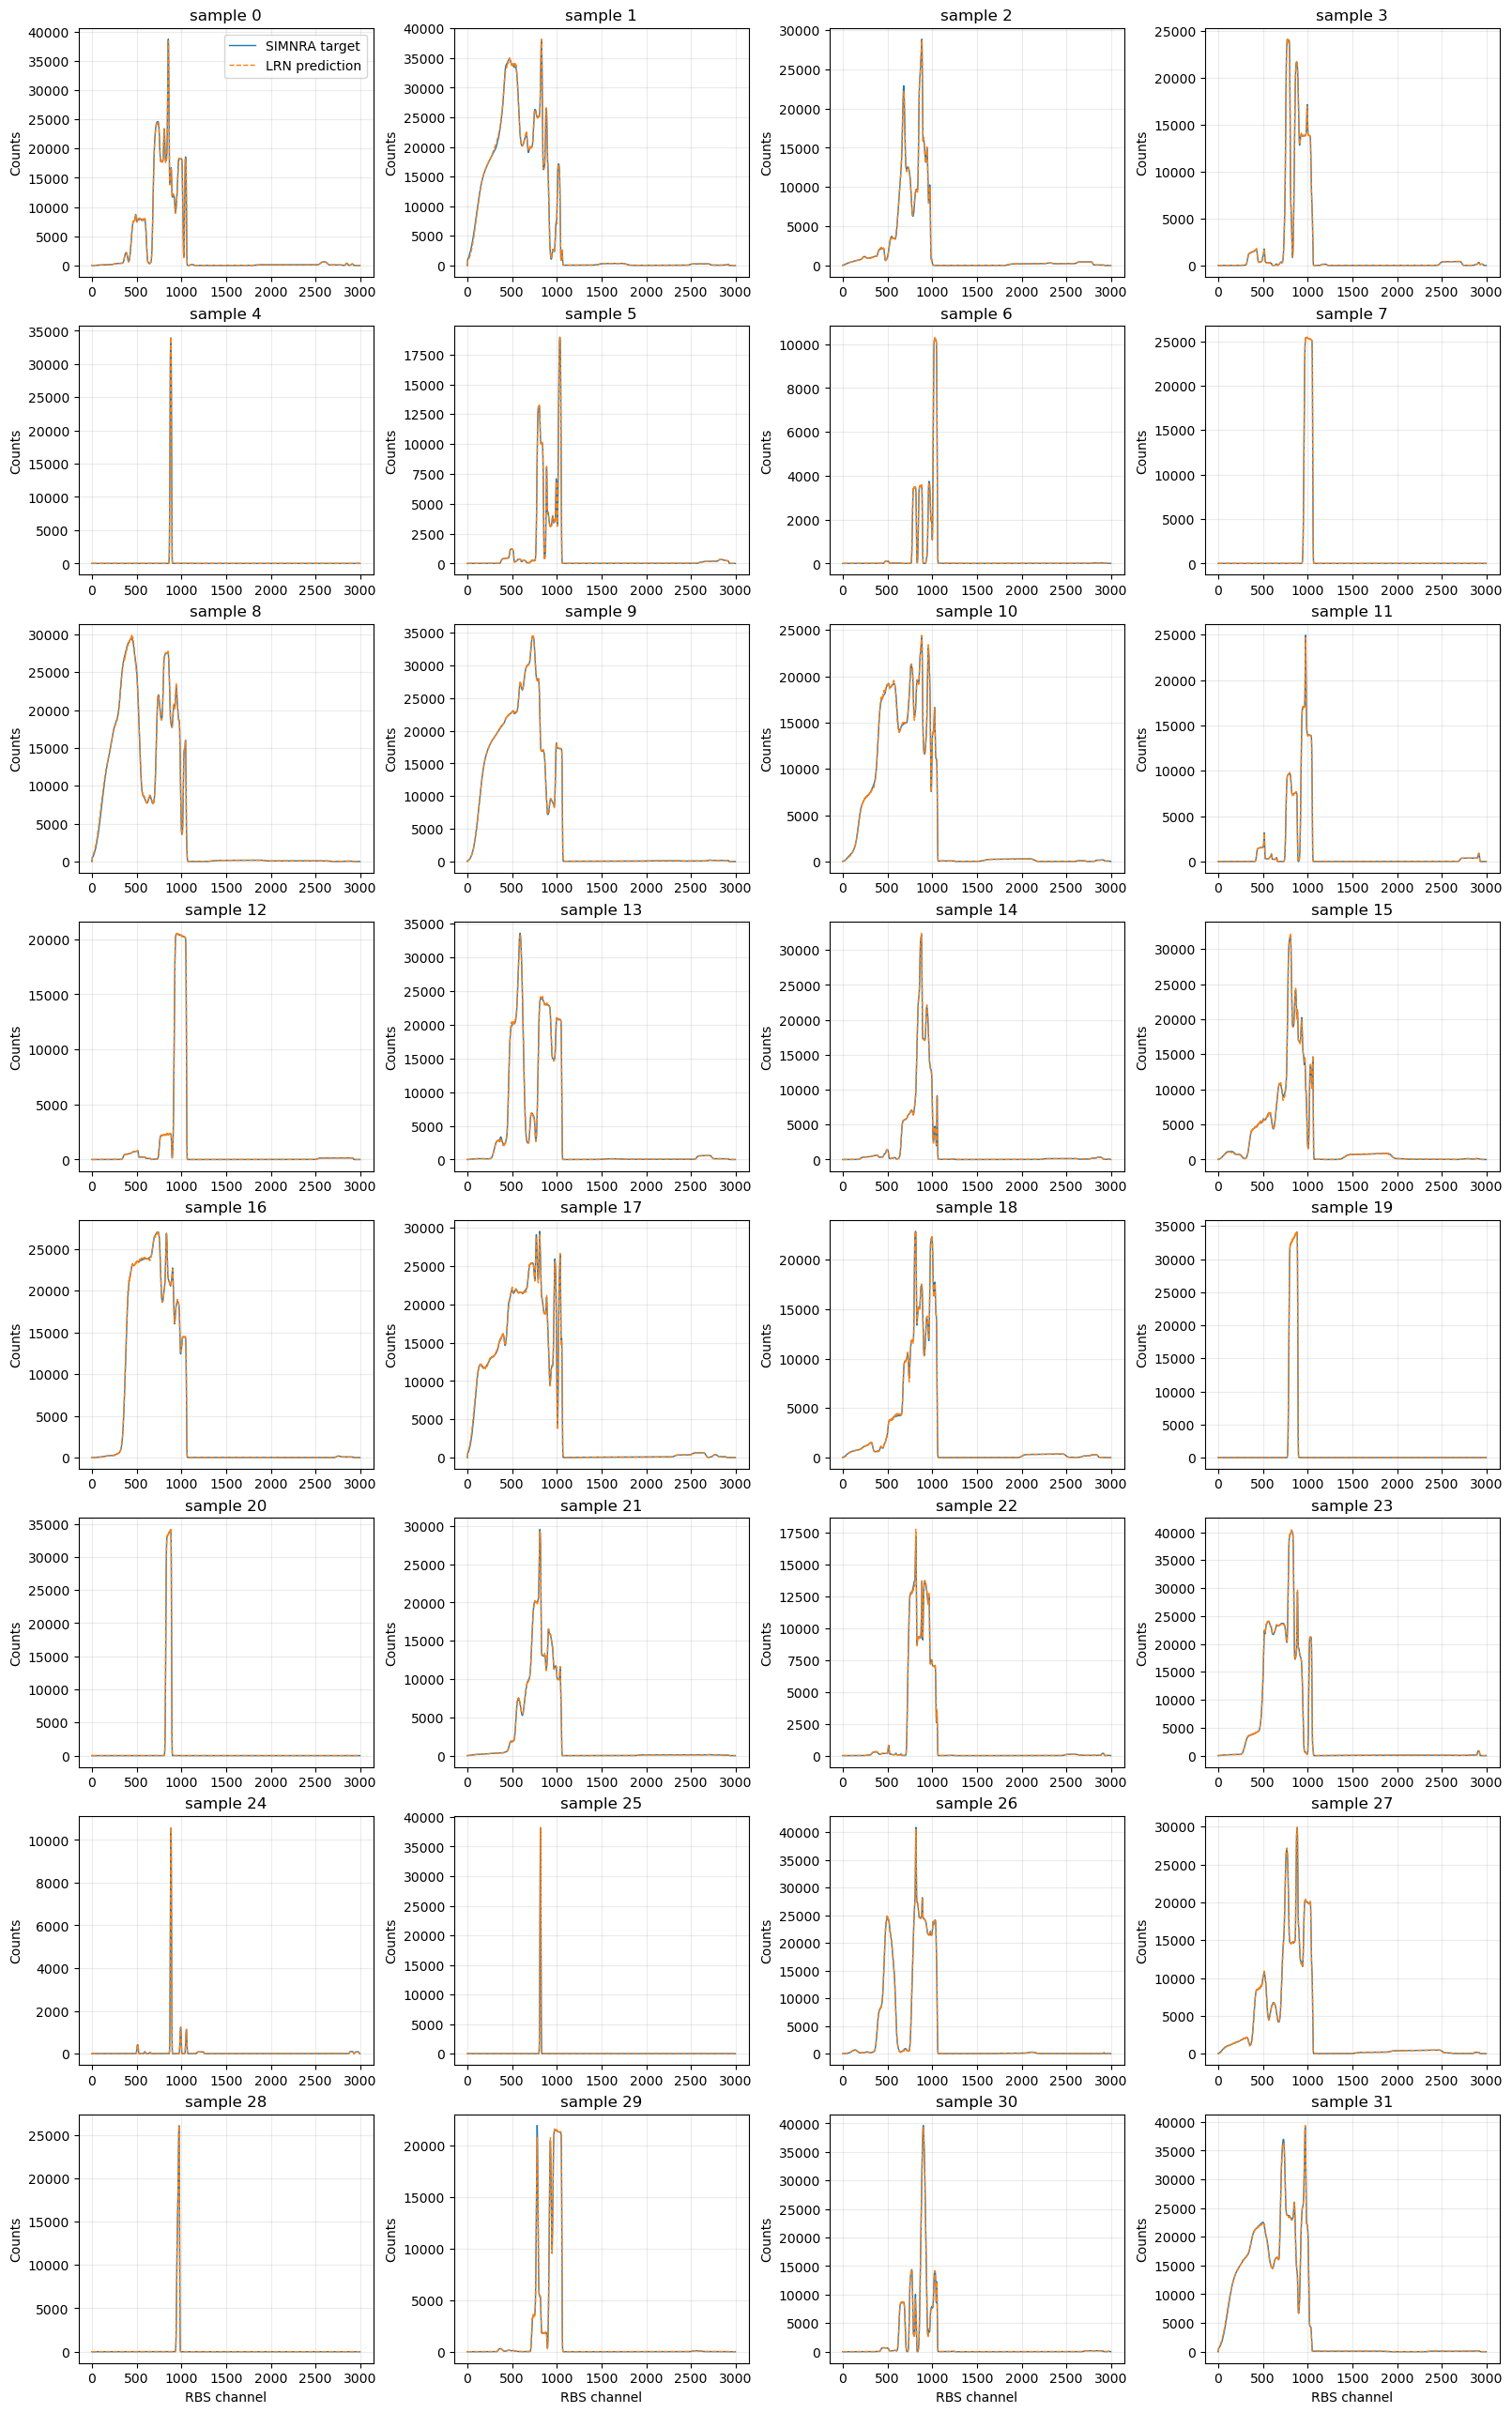

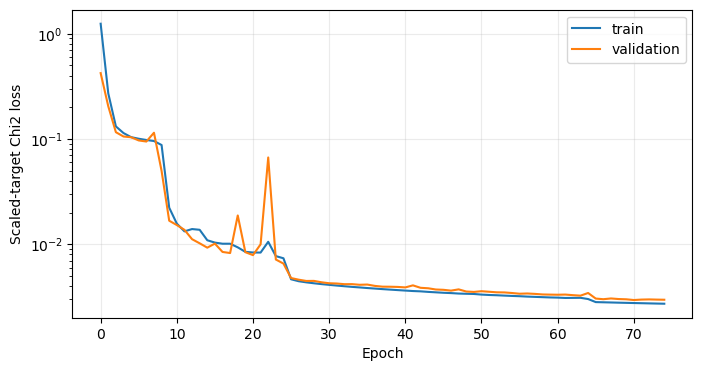

In [24]:
model.eval()
predictions = []
with torch.inference_mode():
    for start in range(0, len(x_test), BATCH_SIZE):
        batch = torch.from_numpy(x_test[start:start + BATCH_SIZE]).to(device)
        predictions.append(model.predict(batch).cpu().numpy())
y_prediction_scaled = np.concatenate(predictions, axis=0)
y_prediction = target_transform.inverse(y_prediction_scaled)

threshold = max(float(y_test.max()) * 1e-3, 1.0)
relative_errors = []
for target, prediction in zip(y_test, y_prediction):
    mask = target > threshold
    if np.any(mask):
        relative_errors.append(float(np.mean(np.abs(prediction[mask] - target[mask]) / target[mask])))

print("Test spectra:", len(y_test))
print("Valid-bin threshold:", threshold, "counts")
if relative_errors:
    print("Median sample relative error:", float(np.median(relative_errors)))
    print("Mean sample relative error:", float(np.mean(relative_errors)))

n_plot = min(32, len(y_test))
plot_columns = 4
plot_rows = (n_plot + plot_columns - 1) // plot_columns
fig, axes = plt.subplots(plot_rows, plot_columns, figsize=(16, 3.2 * plot_rows), squeeze=False, constrained_layout=True)
for index in range(n_plot):
    axis = axes.flat[index]
    axis.plot(y_test[index], label="SIMNRA target", linewidth=1.0)
    axis.plot(y_prediction[index], label="LRN prediction", linestyle="--", linewidth=1.0)
    axis.set_title(f"sample {index}")
    axis.set_ylabel("Counts")
    axis.grid(alpha=0.25)
    if index == 0:
        axis.legend()
for axis in axes.flat[n_plot:]:
    axis.set_visible(False)
for axis in axes[-1, :]:
    if axis.get_visible():
        axis.set_xlabel("RBS channel")
plt.show()

losses = np.asarray(history)
plt.figure(figsize=(8, 4))
plt.plot(losses[:, 0], label="train")
plt.plot(losses[:, 1], label="validation")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Scaled-target Chi2 loss")
plt.grid(alpha=0.25)
plt.legend()
plt.show()


## 7. Save weights and export

The public package accepts physical thickness and valid atomic fractions. ONNX multiplies them and applies the saved AD factor. Package input preprocessing is identity; spectrum scaling and correction metadata follow the original LRN example. Verify native/ONNX predictions against the core network.


In [23]:
# Export settings
OUTPUT_DIR = EXAMPLES / "artifacts" / "lrn_ad_rbs_10layers_final"
BARE_SPECTRUM_CORRECTIONS = True
APPLY_PILEUP_ON_INFERENCE = True
PILEUP_FUDGE_FACTOR_SECONDS = 0.4e-6

# Bare correction metadata requires pileup-free targets and a fixed setup.
if BARE_SPECTRUM_CORRECTIONS:
    if configuration.variations:
        raise ValueError("Bare spectrum corrections require a fixed training setup")
    reference_method = next(method for method in configuration.methods if method.label == METHOD)
    pileup_values = [element.text.strip().lower()
                     for element in ET.parse(reference_method.reference_file).getroot().iter()
                     if element.tag.split("}")[-1].lower() == "pileup" and element.text]
    if not pileup_values or any(value != "false" for value in pileup_values):
        raise ValueError("Bare spectrum corrections require a reference with pileup disabled")
if not np.isfinite(PILEUP_FUDGE_FACTOR_SECONDS) or PILEUP_FUDGE_FACTOR_SECONDS < 0:
    raise ValueError("Pileup fudge factor must be finite and nonnegative")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
weights_path = OUTPUT_DIR / "lrn_ad_state.pt"
package_path = OUTPUT_DIR / f"lrn_ad_{METHOD.lower()}_{MAX_LAYERS}layers.zip"
if package_path.exists():
    raise FileExistsError(f"Refusing to overwrite {package_path}; choose another OUTPUT_DIR.")

# Reload the durable best checkpoint, so export cannot accidentally use live/latest weights.
export_checkpoint = load_checkpoint(best_path)
validate_checkpoint(export_checkpoint)
model.load_state_dict(export_checkpoint["model_state_dict"])
model.to(device)
model.eval()
best_loss = float(export_checkpoint["best_validation_loss"])
best_epoch = export_checkpoint["best_epoch"]
best_history = list(export_checkpoint["history"])
export_validation_loss = evaluate_validation_loss()
if not np.isclose(export_validation_loss, best_loss, rtol=1e-5, atol=1e-8):
    raise RuntimeError("Export validation differs from the protected best; refusing to export")
print(f"Exporting protected best epoch {best_epoch}, validation loss {best_loss:.8g}")

torch.save(
    {
        "model_state_dict": {name: value.detach().cpu() for name, value in model.state_dict().items()},
        "max_layers": MAX_LAYERS,
        "method": METHOD,
        "input_parameter_names": study.parameter_names,
        "elements": list(ELEMENTS),
        "ad_input_factor": AD_INPUT_FACTOR,
        "architecture": model.architecture,
        "output_scale": OUTPUT_SCALE,
        "history": best_history,
        "training_history": history,
        "best_validation_loss": best_loss,
        "best_epoch": best_epoch,
        "layer_representation": "areal_density",
        "thickness_controlled_gru": False,
        "bare_spectrum_corrections": BARE_SPECTRUM_CORRECTIONS,
        "Apply_pileup_on_inference": APPLY_PILEUP_ON_INFERENCE,
        "pileup_fudge_factor_seconds": PILEUP_FUDGE_FACTOR_SECONDS,
    },
    weights_path,
)
model.export(
    package_path,
    output_inverse_factor=OUTPUT_SCALE,
    bare_spectrum_corrections=BARE_SPECTRUM_CORRECTIONS,
    Apply_pileup_on_inference=APPLY_PILEUP_ON_INFERENCE,
    pileup_fudge_factor_seconds=PILEUP_FUDGE_FACTOR_SECONDS,
)

print("Saved weights:", weights_path)
print("Exported iBeamLab package:", package_path)
print("Package input transform: identity; AD conversion/scaling embedded in ONNX")
print("Package output transform: inverse constant-factor scaling (applied by native inference)")

# Check the actual package, including reference setup and reversible scaling.
with zipfile.ZipFile(package_path) as archive:
    package_metadata = tomllib.loads(archive.read("package.toml").decode("utf-8"))
forward_metadata = package_metadata["forward"]
assert forward_metadata["bare_spectrum_corrections"] == BARE_SPECTRUM_CORRECTIONS
assert forward_metadata["Apply_pileup_on_inference"] == APPLY_PILEUP_ON_INFERENCE
assert np.isclose(forward_metadata["pileup_fudge_factor_seconds"], PILEUP_FUDGE_FACTOR_SECONDS)
assert len(forward_metadata["sample_template"]["layers"]) == MAX_LAYERS
assert [p["name"] for p in forward_metadata["input_parameters"]] == list(study.parameter_names)
input_metadata = package_metadata["transforms"]["input"]
assert input_metadata["type"] == "identity"
output_metadata = package_metadata["transforms"]["output"]
assert output_metadata["type"] == "constant_factor"
assert np.isclose(output_metadata["factor"], OUTPUT_SCALE)
reference = next(d for d in forward_metadata["setup_template"]["detectors"] if d["label"] == METHOD)
training_detector = next(d for d in study.experiment.detectors if d.label == METHOD)
for field in ("resolution", "particles_sr", "real_time", "live_time"):
    assert np.isclose(reference[field], getattr(training_detector, field)), field
print("Verified correction metadata:", {
    key: forward_metadata[key] for key in (
        "bare_spectrum_corrections", "Apply_pileup_on_inference", "pileup_fudge_factor_seconds"
    )
})
print("Reference detector:", reference)

# Compare native inference directly with scaled-AD PyTorch predictions.
check_count = min(8, len(x_test))
native_model = ibl.ForwardModel(package_path, apply_pileup_on_inference=False)
with torch.inference_mode():
    expected = model(torch.from_numpy(x_test[:check_count]).to(device)).cpu().numpy() / OUTPUT_SCALE
experiments = []
for row in x_test_raw[:check_count]:
    layers = []
    for layer in range(MAX_LAYERS):
        values = {p.kind if p.kind == 'layer_thickness' else p.element: float(v)
                  for p, v in zip(study.parameters, row) if p.layer == layer}
        if values['layer_thickness'] > 0:
            layers.append(ibl.Layer(values['layer_thickness'], {e: values[e] for e in ELEMENTS}))
    experiments.append(ibl.Experiment(ibl.Sample(layers), study.experiment.detectors))
actual = np.stack([result[METHOD].counts for result in native_model.predict(experiments)])
np.testing.assert_allclose(actual, expected, rtol=2e-4, atol=1e-3)
print("Native/PyTorch AD parity verified")


Exporting protected best epoch 71, validation loss 0.0029555829
Saved weights: D:\ibeamlab\examples\artifacts\lrn_ad_rbs_10layers_final\lrn_ad_state.pt
Exported iBeamLab package: D:\ibeamlab\examples\artifacts\lrn_ad_rbs_10layers_final\lrn_ad_rbs_10layers.zip
Package input transform: identity; AD conversion/scaling embedded in ONNX
Package output transform: inverse constant-factor scaling (applied by native inference)
Verified correction metadata: {'bare_spectrum_corrections': True, 'Apply_pileup_on_inference': True, 'pileup_fudge_factor_seconds': 4e-07}
Reference detector: {'beam_energy': 2974.0, 'beam_spread': 0.0, 'calibration_linear': 2.63714, 'calibration_offset': 0.0, 'calibration_quadratic': 0.0, 'info': '', 'label': 'RBS', 'live_time': 0.001, 'particle': 'H', 'particles_sr': 1000000000000.0, 'real_time': 0.001, 'resolution': 20.0}
Native/PyTorch AD parity verified


## 8. Check deeper-layer generalization

If datasets beyond `MAX_LAYERS` are present, this evaluates eager PyTorch inference on those variable-length inputs and writes comparison plots. The exported C++ package remains fixed to the training layout.

In [ ]:
deeper_counts = 0

deep_dataset_paths = sorted(
    path
    for layer_count, paths in LAYER_DATASETS.items()
    if MAX_LAYERS < layer_count <= configuration.maximum_layers
    for path in paths
)
for dataset_path in deep_dataset_paths:
    layer_count = int(re.fullmatch(r"layers_(\d+)", dataset_path.name).group(1))
    dataset = ibl.open_dataset(dataset_path)
    if not dataset.metadata.complete or METHOD not in dataset.metadata.spectrum_labels:
        print(f"Skipping unavailable generalization dataset: {dataset_path}")
        continue

    case_study = configuration.study(layer_count)
    case_names = case_study.parameter_names
    source_names = dataset.metadata.parameter_names
    if set(source_names) != set(case_names):
        raise ValueError(f"Unexpected parameter layout in {dataset_path}")
    source_columns = {name: column for column, name in enumerate(source_names)}
    raw_inputs = np.asarray(dataset.parameters, dtype=np.float32)
    ordered_inputs = raw_inputs[:, [source_columns[name] for name in case_names]]
    scaled_inputs = physical_to_ad(ordered_inputs, case_study) * AD_INPUT_FACTOR

    case_predictions = []
    model.eval()
    with torch.inference_mode():
        for start in range(0, len(scaled_inputs), BATCH_SIZE):
            batch = torch.from_numpy(scaled_inputs[start:start + BATCH_SIZE]).to(device, non_blocking=PIN_MEMORY)
            case_predictions.append(model.predict(batch).cpu().numpy())
    case_predictions = target_transform.inverse(np.concatenate(case_predictions, axis=0))
    case_targets = np.asarray(dataset.spectra(METHOD), dtype=np.float32)
    common_width = min(case_targets.shape[1], case_predictions.shape[1])
    case_targets = case_targets[:, :common_width]
    case_predictions = case_predictions[:, :common_width]
    deeper_counts += len(case_targets)
    print(f"Generalization {layer_count} layers: {len(case_targets):,} samples from {dataset_path}")

    n_plot = min(4, len(case_targets))
    fig, axes = plt.subplots(n_plot, 1, figsize=(12, 2.8 * n_plot), squeeze=False, constrained_layout=True)
    for index in range(n_plot):
        axes[index, 0].plot(case_targets[index], label="SIMNRA target", linewidth=1.0)
        axes[index, 0].plot(case_predictions[index], label="LRN prediction", linestyle="--", linewidth=1.0)
        axes[index, 0].set_ylabel(f"sample {index}")
        axes[index, 0].grid(alpha=0.25)
        if index == 0:
            axes[index, 0].legend()
    axes[-1, 0].set_xlabel("RBS channel")
    plt.show()

if deeper_counts == 0:
    print(f"No datasets with more than {MAX_LAYERS} layers found (configuration limit: {configuration.maximum_layers}).")
